# 3-body problem

$$H(p,q) = \frac{1}{2}\left( \frac{p_1^2}{m_1} + \frac{p_2^2}{m_2} + \frac{p_3^2}{m_3}\right) - \frac{G m_1 m_2}{\| q_1 - q_2 \|} - \frac{G m_1 m_3}{\| q_1 - q_3 \|} - \frac{G m_2 m_3}{\| q_2 - q_3 \|} $$ 

$$\frac{d q_i}{dt} = \frac{p_i}{m_i}, \quad i=1,2,3 $$

$$\frac{d p_1}{dt} = - G m_1 \left(m_2 \frac{q_1 - q_2}{\| q_1 - q_2 \|^3} + m_3 \frac{q_1 - q_3}{\| q_1 - q_3 \|^3}\right) $$
$$\frac{d p_2}{dt} = - G m_2 \left(m_1 \frac{q_2 - q_1}{\| q_1 - q_2 \|^3} + m_3 \frac{q_2 - q_3}{\| q_2 - q_3 \|^3}\right) $$
$$\frac{d p_3}{dt} = - G m_3 \left(m_1 \frac{q_3 - q_1}{\| q_1 - q_3 \|^3} + m_2 \frac{q_3 - q_2}{\| q_2 - q_3 \|^3}\right) $$

Sun-Earth-Moon system 

- Parameters: $G=1, m_1=100, m_2=1, m_3=0.001$

- Initial condition: 
$$
\begin{align} 
    p_1(0) &= [0,     -1.0001,     -0.0001   ] \\
    p_2(0) &= [0,     1,     0  ] \\
    p_3(0) &= [0,     0.0001,    0.0001   ] \\
    q_1(0) &= [-1.00102,     0,     0   ] \\
    q_2(0) &= [100,     0,    0  ] \\
    q_3(0) &= [102,     0,    0   ]
\end{align} 
$$

Conservation of total momentum 
$$P(p) = p_1 + p_2 + p_3 $$

Conservation of total angular momentum 
$$L(p,q) = q_1 \times p_1 + q_2 \times p_2 + q_3 \times p_3 $$

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dataprocessing_utils.threebody import ThreeBody, ThreeBodyDataset, ThreeBodyTrajectory, REF_TRAJ_DT, REF_TRAJ_FILEPATHS

Trajectory = ThreeBodyTrajectory
Dataset = ThreeBodyDataset

In [2]:
# Plotting functions

def plot_phase_space(dataset_or_trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(18, 3), show_legend=False, save_path=None):

    if axis_lims is None:
        # axis_lims = [[(-5., 5.), (-1.5, 1.5)]] * 9  # Default axis limits for all subplots
        axis_lims = [[None, None]] * 9  # Default axis limits for all subplots

    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    elif isinstance(linestyles, str):
        linestyles = [linestyles] * len(dataset_or_trajs)

    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$q_{1x}$', '$p_{1x}$'), ('$q_{1y}$', '$p_{1y}$'), ('$q_{1z}$', '$p_{1z}$'), 
                       ('$q_{2x}$', '$p_{2x}$'), ('$q_{2y}$', '$p_{2y}$'), ('$q_{2z}$', '$p_{2z}$'),
                       ('$q_{3x}$', '$p_{3x}$'), ('$q_{3y}$', '$p_{3y}$'), ('$q_{3z}$', '$p_{3z}$')]  # Default axis labels

    fig, axes = plt.subplots(1, 9, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes
    
    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        (p1, p2, p3), (q1, q2, q3) = traj.states.get_pq()
        p = np.concatenate((p1, p2, p3), axis=-1)
        q = np.concatenate((q1, q2, q3), axis=-1)
        if legend_label == 'ref':
            line1, = axes[0].plot(q[:, 0], p[:, 0], linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            for i in range(1, 9):
                axes[i].plot(q[:, i], p[:, i], linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0].plot(q[:, 0], p[:, 0], linestyle, lw=1, label=legend_label)
            for i in range(1, 9):
                axes[i].plot(q[:, i], p[:, i], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        if titles is not None:
            ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_phase_space_3d(dataset_or_trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(12, 4), show_legend=False, save_path=None):
    
    if axis_lims is None:
        # axis_lims = [[(-5., 5.), (-5., 5.), (-5., 5.)]] * 3  # Default axis limits for all subplots
        axis_lims = [[None, None, None]] * 3  # Default axis limits for all subplots

    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$q_{1x}$', '$q_{1y}$', '$q_{1z}$'), 
                       ('$q_{2x}$', '$q_{2y}$', '$q_{2z}$'),
                       ('$q_{3x}$', '$q_{3y}$', '$q_{3z}$')]  # Default axis labels

    if titles is None:
        titles = ['Body 1', 'Body 2', 'Body 3']  # Default titles for subplots

    fig = plt.figure(figsize=figsize, layout='constrained')
    axes = fig.subplots(1, 3, subplot_kw={'projection': '3d'})  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        _, (q1, q2, q3) = traj.states.get_pq()
        if legend_label == 'ref':
            line1, = axes[0].plot(q1[:, 0], q1[:, 1], q1[:, 2], linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[1].plot(q2[:, 0], q2[:, 1], q2[:, 2], linestyle, lw=1, color='k', alpha=0.3)
            axes[2].plot(q3[:, 0], q3[:, 1], q3[:, 2], linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0].plot(q1[:, 0], q1[:, 1], q1[:, 2], linestyle, lw=1, label=legend_label)
            axes[1].plot(q2[:, 0], q2[:, 1], q2[:, 2], linestyle, lw=1)
            axes[2].plot(q3[:, 0], q3[:, 1], q3[:, 2], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
            ax.set_zlim(axis_lims[i][2])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_zlabel(axis_labels[i][2])
        ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_phase_space_3d_together(dataset_or_traj, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     title=None, figsize=(6, 4), show_legend=False, save_path=None):
    
    if axis_lims is None:
        axis_lims = [None, None, None]  # Default axis limits 

    if linestyles is None:
        linestyles = ['-'] * 3  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Body 1', 'Body 2', 'Body 3']

    if axis_labels is None:
        axis_labels = ['x', 'y', 'z']  # Default axis labels

    fig = plt.figure(figsize=figsize, layout='constrained')
    ax = fig.subplots(1, 1, subplot_kw={'projection': '3d'})  # Use plt.subplots to manage multiple axes

    _, (q1, q2, q3) = dataset_or_traj.states.get_pq()
    ax.plot(q1[:, 0], q1[:, 1], q1[:, 2], linestyles[0], lw=1, label=legend_labels[0])
    ax.plot(q2[:, 0], q2[:, 1], q2[:, 2], linestyles[1], lw=1, label=legend_labels[1])
    ax.plot(q3[:, 0], q3[:, 1], q3[:, 2], linestyles[2], lw=1, label=legend_labels[2])

    # Set labels and titles for each subplot
    ax.set_xlim(axis_lims[0])
    ax.set_ylim(axis_lims[1])
    ax.set_zlim(axis_lims[2])
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_zlabel(axis_labels[2])
    ax.set_title(title)

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_history(dataset_or_trajs, func_dict, linestyles=None, alpha=1., legend_labels=None, xlabel="t", ylabels=None, ylims=None, 
               figsize=None, show_legend=True, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict.keys())
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        xdata = traj.times if isinstance(traj, Trajectory) else np.arange(len(traj))
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                if legend_label == 'ref':
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                else:
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
            else:
                if legend_label == 'ref':
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                else:
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabels[i])
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabels[0])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 


def plot_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, titles=None, error_names=None, 
                ylims=None, ylabels=None, figsize=None, log_yscale=True, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]
    
    if ylims is None:
        ylims = [(1e-5, 1e1)] * len(error_names)  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = error_names  # Default y axis labels
    
    if figsize is None:
        figsize = (8, 1.5 * len(error_names))

    fig, axes = plt.subplots(len(error_names), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        tt, errors = traj.compare(ref_traj)
        for i, error_name in enumerate(error_names):
            if len(error_names) > 1:
                line1, = axes[i].plot(tt, errors[error_name], linestyle, lw=1, label=legend_label)
            else:
                line1, = axes.plot(tt, errors[error_name], linestyle, lw=1, label=legend_label)
        lines.append(line1)
        # line1, = axes[0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
        # axes[1].plot(tt, errors[error_names[1]], linestyle, lw=1)
        # lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        if log_yscale:
            ax.set_yscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return



In [3]:
def corrplot(dataset_or_trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(18, 18), show_legend=False, save_path=None):

    if axis_lims is None:
        # axis_lims = [[(-5., 5.), (-1.5, 1.5)]] * 9  # Default axis limits for all subplots
        axis_lims = [[None, None]] * 18  # Default axis limits for all subplots

    if linestyles is None:
        linestyles = ['.'] * len(dataset_or_trajs)  # Default linestyle for all plots
    elif isinstance(linestyles, str):
        linestyles = [linestyles] * len(dataset_or_trajs)

    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = ['$q_{1x}$', '$q_{1y}$', '$q_{1z}$', '$q_{2x}$', '$q_{2y}$', '$q_{2z}$', '$q_{3x}$', '$q_{3y}$', '$q_{3z}$', \
                       '$p_{1x}$', '$p_{1y}$', '$p_{1z}$', '$p_{2x}$', '$p_{2y}$', '$p_{2z}$', '$p_{3x}$', '$p_{3y}$', '$p_{3z}$']  # Default axis labels

    fig, axes = plt.subplots(18, 18, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes
    
    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        u = traj.states.u
        if legend_label == 'ref':
            line1, = axes[0,0].plot(u[:, 0], u[:, 0], linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            for i in range(1, 18):
                for j in range(i+1):
                    axes[i,j].plot(u[:, i], u[:, j], linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0,0].plot(u[:, 0], u[:, 0], linestyle, lw=1, label=legend_label)
            for i in range(1, 18):
                for j in range(i+1):
                    axes[i,j].plot(u[:, i], u[:, j], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i in range(18):
        for j in range(18):
            axes[i,j].set_xlim(axis_lims[i])
            axes[i,j].set_ylim(axis_lims[j])
            axes[i,j].set_xlabel(axis_labels[i])
            axes[i,j].set_ylabel(axis_labels[j])
            if titles is not None:
                axes[i,j].set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return



## Usage example

ThreeBodyTrajectory(t_range=[0.0, 10000.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1000001, 18)))


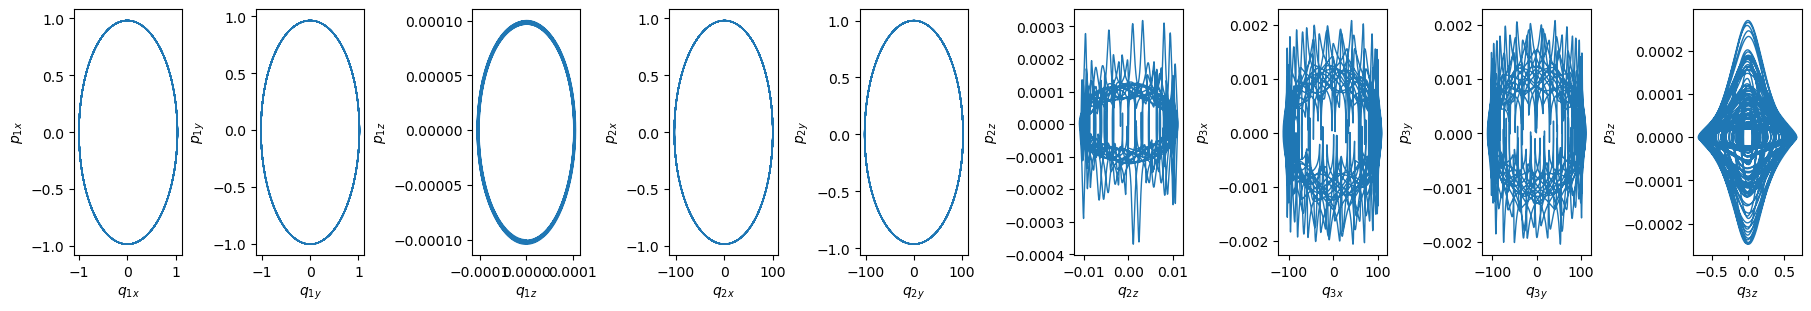

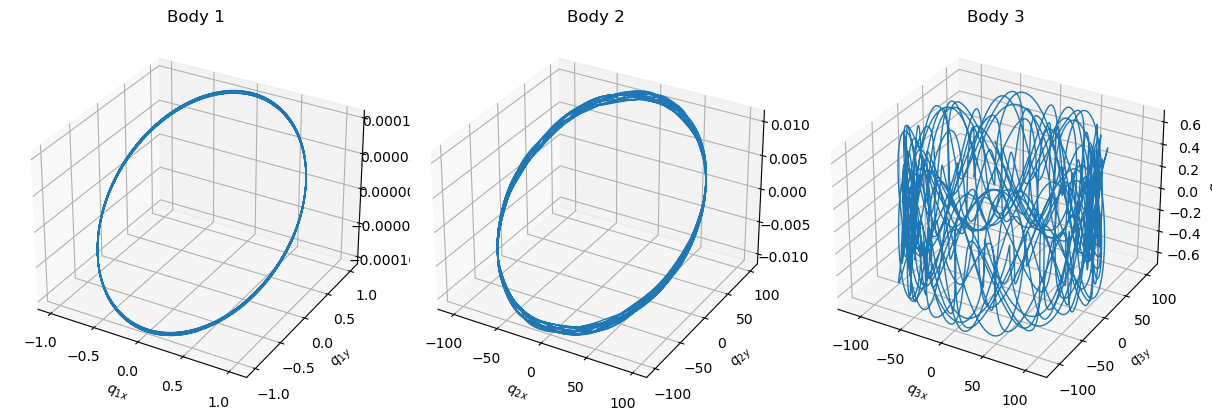

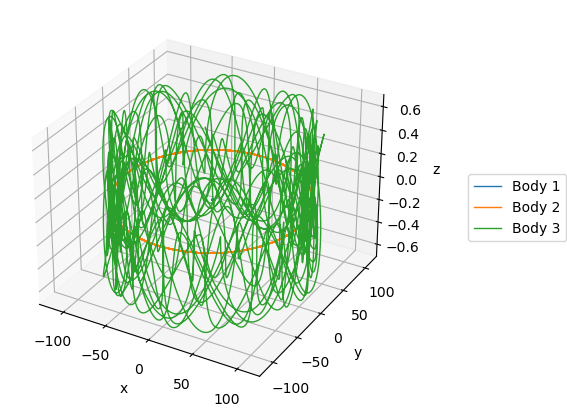

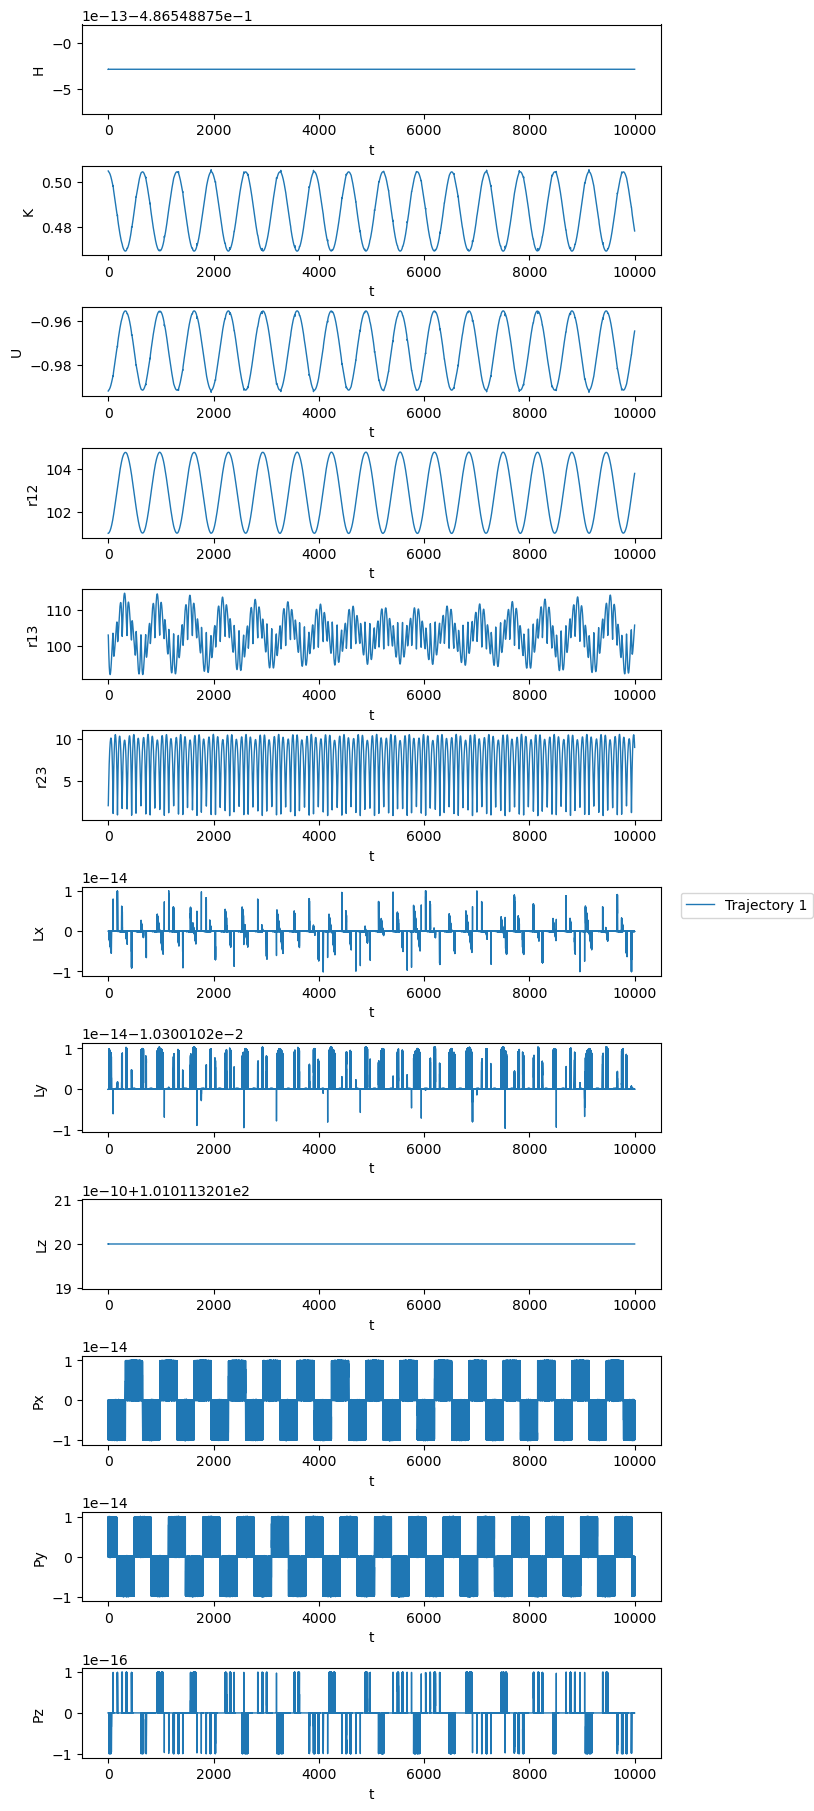

In [4]:
# Sun-Earth-Moon system
ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[1], dt=REF_TRAJ_DT, m1=100., m2=1., m3=0.001)

threebody = ThreeBody(m1=100., m2=1., m3=0.001)
func_dict = {
    "H": threebody.compute_hamiltonian,
    "K": threebody.compute_kinetic_energy,
    "U": threebody.compute_potential_energy,
    "r12": threebody.compute_r12,
    "r13": threebody.compute_r13,
    "r23": threebody.compute_r23,
    "Lx": lambda u: threebody.compute_total_angular_momentum(u)[:, 0],
    "Ly": lambda u: threebody.compute_total_angular_momentum(u)[:, 1],
    "Lz": lambda u: threebody.compute_total_angular_momentum(u)[:, 2],
    "Px": lambda u: threebody.compute_total_momentum(u)[:, 0],
    "Py": lambda u: threebody.compute_total_momentum(u)[:, 1],       
    "Pz": lambda u: threebody.compute_total_momentum(u)[:, 2],
}

traj = ref_traj.select_between(0, 10000)
print(traj)
plot_phase_space([traj])
plot_phase_space_3d([traj])
plot_phase_space_3d_together(traj, show_legend=True)
plot_history([traj], func_dict, xlabel="t")

## Load model checkpoints

In [5]:
import sys
sys.path.append("../deep_learning/src")

import re 
import torch

from utils.checkpoint_utils import load_model_from_ckpt
from modules.variable_timestep import T0CenteredSolutionMap
from datamodules.datasets import get_sequence_data

In [6]:
def dPhidt(model):
    return lambda u, t: torch.func.vmap(torch.func.jacrev(model, argnums=1))(u, t).squeeze(-1)  # (bs, 2*dof)

def get_epoch_from_ckpt(ckpt_path):
    # Search for pattern 'epoch' followed by digits
    match = re.search(r'epoch(\d+)', ckpt_path)
    if match:
        return int(match.group(1))
    return None

def load_checkpoint_history(ckpt_dir, model_name):
    ckpt_paths = glob.glob(ckpt_dir + "/*epoch*.ckpt")
    ckpt_paths = sorted(ckpt_paths, key=lambda ckpt: get_epoch_from_ckpt(ckpt))

    model_ckpts = {}
    for path in ckpt_paths:
        model_ckpts[f"epoch{get_epoch_from_ckpt(path)}"] = {
            "model_name": model_name,
            "ckpt_path": path
        }
    return model_ckpts

def find_latest_ckpt(ckpt_dir):
    latest_ckpt = glob.glob(f"{ckpt_dir}/latest*.ckpt")
    if latest_ckpt:
        return latest_ckpt[0]
    else:
        raise FileNotFoundError(f"No latest checkpoint found in {ckpt_dir}")
    
def get_batch(batch_size, data_dir, t_range=None, t=None):
    data_config = {
        "data_dir": data_dir,
        "sequence_len": 2, 
        "dtype": "float64",
        "downsample_factor": 1,
        "Dt_range": t_range,
        "Dt": t
    }
    ds = get_sequence_data(data_config)
    return ds[:batch_size]

In [7]:
def plot_deriv_error_statistics_vs_t(model_ckpts, batch, bins=41, t_range=None, ylim=None, log_yscale=True, 
                                        legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""
    
    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            print(f"Skipping {label} because it is a FixedStepSolutionMap")
            continue 
        
        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        u0 = batch["input"].to(model.dtype).to(model.device)
        u1 = batch["target_seq"][1].to(model.dtype).to(model.device)
        t = batch["Dt"].to(model.dtype).to(model.device)

        true_deriv = model.problem.compute_du(u1)
        pred_deriv = dPhidt(model)(u0, t)

        # true_deriv = model.problem.nondim_du(true_deriv)
        # pred_deriv = model.problem.nondim_du(pred_deriv)

        errors = torch.nn.functional.mse_loss(pred_deriv, true_deriv, reduction="none").sum(-1).sqrt()
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        print("true deriv", true_deriv[:5])
        print("pred deriv", pred_deriv[:5])
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 

    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|d\Phi/dt - d\phi/dt|$')
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()


def plot_fitting_error_statistics_vs_t(model_ckpts, batch, error_name="abs_traj_err", 
                                       bins=41, t_range=None, ylim=None, log_yscale=True, 
                                        legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""
    
    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):

        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        u0 = batch["input"].to(model.dtype).to(model.device)
        u1 = batch["target_seq"][1].to(model.dtype).to(model.device)
        t = batch["Dt"].to(model.dtype).to(model.device)

        true = u1
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            pred = model(u0, None, 2)[1]
        else:
            pred = model(u0, t)

        errors = model.problem.compute_errors(pred, true, reduction="none")[error_name]
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 

    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel(error_name)
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()


def plot_numerical_residual_error_statistics_vs_t(model_ckpts, batch, 
                               vv_config=None, bins=41, t_range=None, ylim=None, log_yscale=True, 
                               legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""
    
    
    if vv_config is None: 
        vv_config = {"method": "VelocityVerlet", "stepsize": 1e-3, "nsteps": 1}

    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            print(f"Skipping {label} because it is a FixedStepSolutionMap")
            continue

        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        vv = model._instantiate_integrator(vv_config)

        u0 = batch["input"].to(model.dtype).to(model.device)
        # t = batch["Dt"].to(model.dtype).to(model.device)
        t = model._prepare_random_timesteps(len(u0), {"type": "uniform", "min": t_range[0], "max": t_range[1]})

        errors = model._calc_numerical_residual_error(u0, t, vv, reduction="none", use_mse=True).sum(dim=-1).sqrt()  # (bs,)
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 
  
    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|VV_h(\Phi(t)) - \Phi(t+h)|$')
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()


def plot_residual_error_statistics_vs_t(model_ckpts, batch,
                                    bins=41, t_range=None, ylim=None, log_yscale=True, 
                               legend_labels=None, figsize=(8, 6), plot_fit=False):
    """Plot statistical measures of error over binned time intervals for multiple models."""

    if legend_labels is None:
        legend_labels = list(model_ckpts.keys()) 

    fig, ax = plt.subplots(figsize=figsize)
    
    # Loop through each group
    for ckpt_info, label in zip(model_ckpts.values(), legend_labels):
        if ckpt_info["model_name"] == "FixedStepSolutionMap":
            print(f"Skipping {label} because it is a FixedStepSolutionMap")
            continue 

        model, _ = load_model_from_ckpt(ckpt_info["ckpt_path"], ckpt_info["model_name"])

        u0 = batch["input"].to(model.dtype).to(model.device)
        # t = batch["Dt"].to(model.dtype).to(model.device)
        t = model._prepare_random_timesteps(len(u0), {"type": "uniform", "min": t_range[0], "max": t_range[1]})


        errors = model._calc_residual_error(u0, t, reduction="none").sum(dim=-1).sqrt()  # (bs,)
        errors = errors.detach().cpu().numpy()
        t = t.detach().cpu().numpy().squeeze()
        
        tmin, tmax = t_range if t_range is not None else (min(t), max(t))
        if isinstance(bins, int):
            bins = np.linspace(tmin, tmax, bins + 1)

        bin_indices = np.digitize(t, bins) - 1
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        min_errors = np.zeros(len(bin_centers))
        max_errors = np.zeros(len(bin_centers))
        mean_errors = np.zeros(len(bin_centers))
        std_errors = np.zeros(len(bin_centers))

        for i in range(len(bin_centers)):
            bin_errors = errors[bin_indices == i]
            if bin_errors.size > 0:
                min_errors[i] = bin_errors.min()
                max_errors[i] = bin_errors.max()
                mean_errors[i] = bin_errors.mean()
                std_errors[i] = bin_errors.std()
            else:
                min_errors[i] = max_errors[i] = mean_errors[i] = std_errors[i] = np.nan
        
        # Plot for the current group
        markers, caps, bars = ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='^',
                    elinewidth=2, capsize=2, label=label)
        [bar.set_alpha(0.5) for bar in bars]
        marker_color = markers.get_color() 
 
    if log_yscale:
        ax.set_yscale('log')
    ax.set_xlim(tmin, tmax)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_xscale('log')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$|d\Phi(t)/dt - F(\Phi(t))|$')
    ax.set_title('Error Statistics vs t')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.show()

IdentityEnforced: Data uniform(-10,10) {'model_name': 'IdentityEnforcedSolutionMap', 'ckpt_dir': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-003511_hfz5i3/checkpoints', 'ckpt_path': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-003511_hfz5i3/checkpoints/latest-epoch00639.ckpt'}
IdentityEnforced: VV normal(0,5) + Data uniform(0,0.1) {'model_name': 'IdentityEnforcedSolutionMap', 'ckpt_dir': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-024301_kzqgyd/checkpoints', 'ckpt_path': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-024301_kzqgyd/checkpoints/latest-epoch06329.ckpt'}
IdentityEnforced: VV normal(0,5) {'model_name': 'IdentityEnforcedSolutionMap', 'ckpt_dir': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241107-155033_watfae/checkpoints', 'ckpt_path': '/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241107-155033_watfa

/workspace/projects_rui/learnsolnmap/notebooks/../deep_learning/src/utils/checkpoint_utils.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_

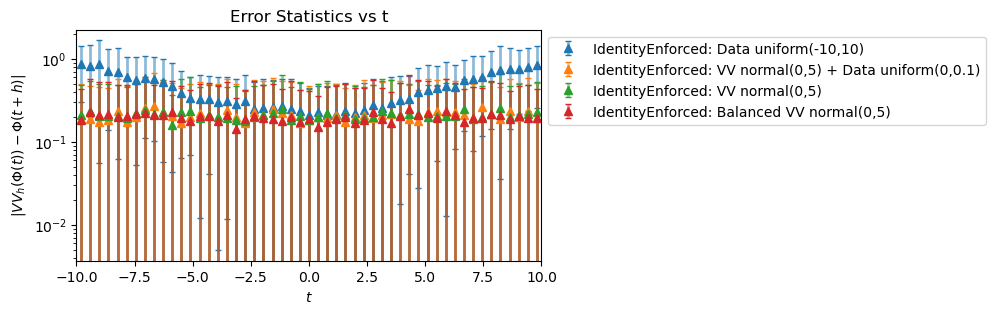

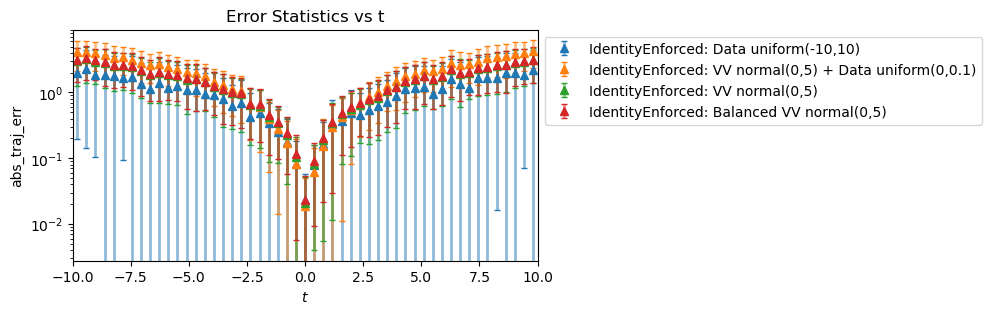

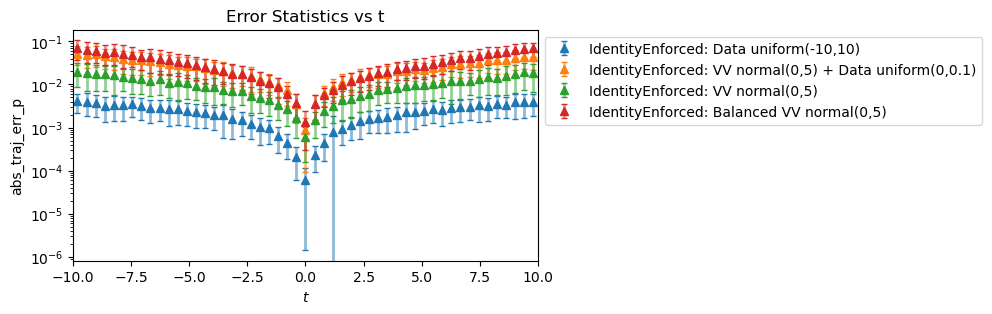

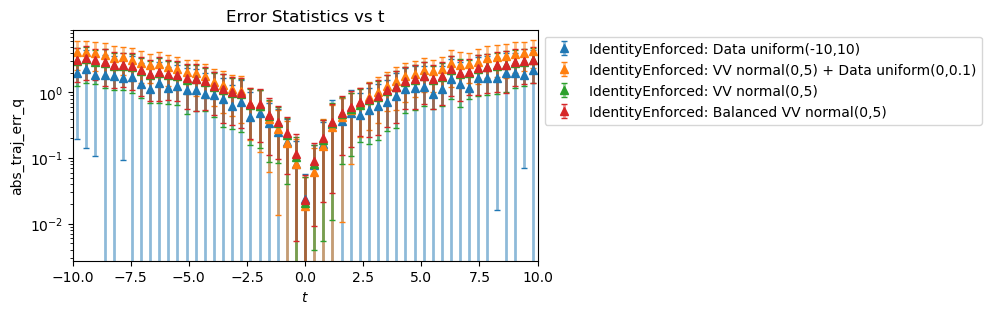

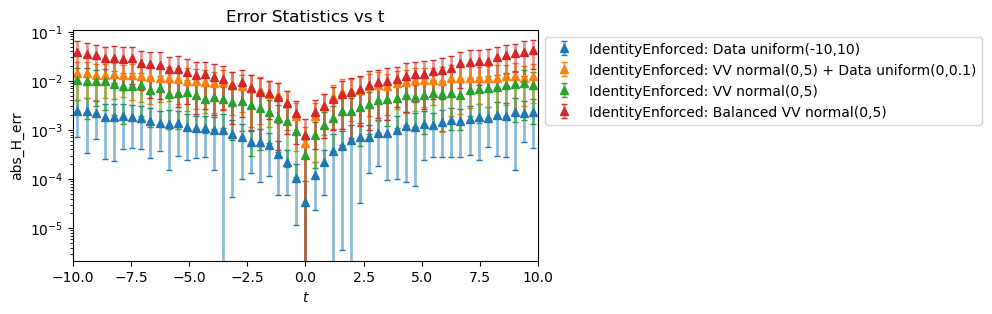

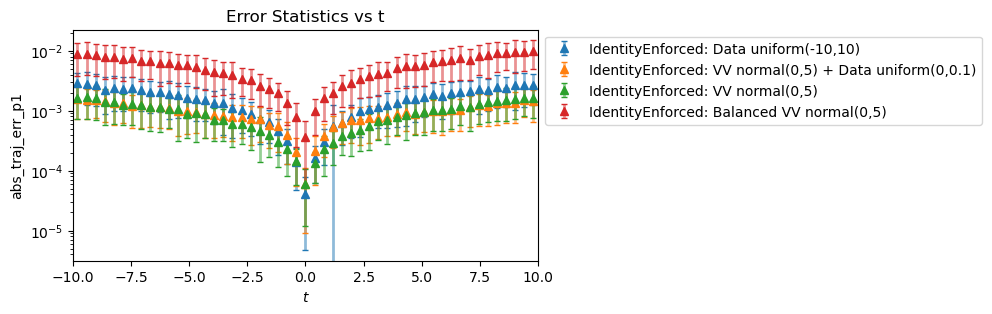

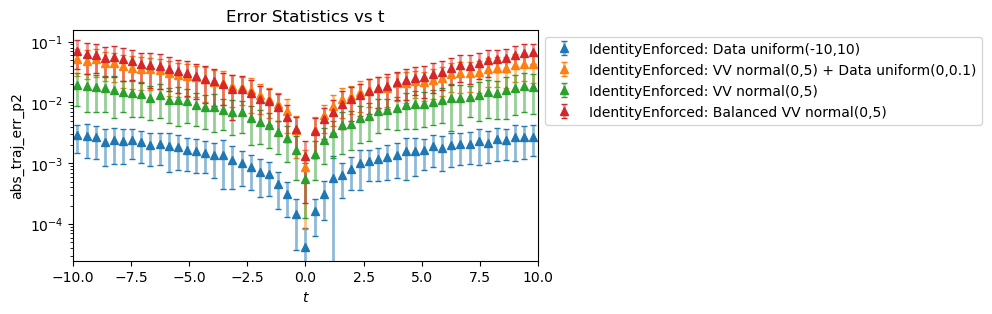

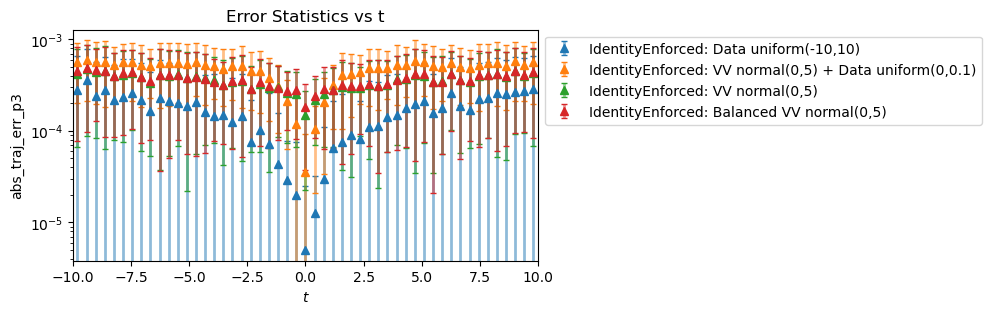

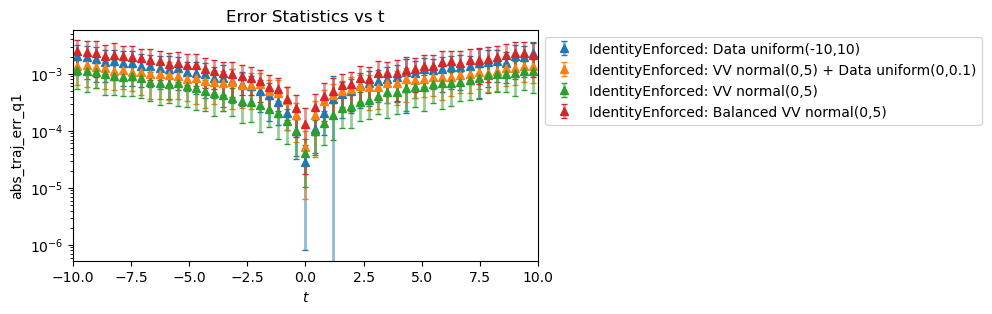

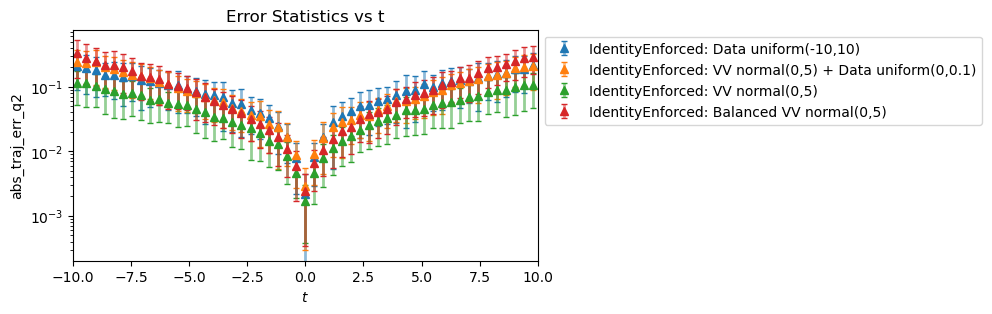

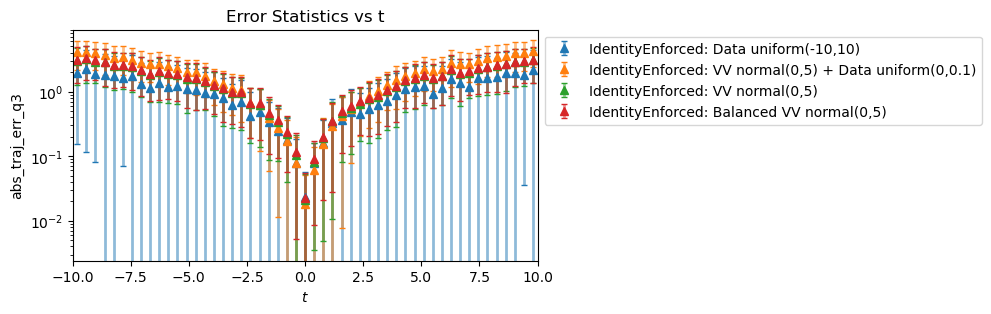

In [8]:
# Load latest checkpoint in given directories

# version 3 dataset 
# model_ckpts = {
#     "IdentityEnforced: Data uniform(-10,10)": {
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241104-230253_df7nxn/checkpoints",
#     },
#     "IdentityEnforced: VV normal(0,5)": {
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241105-010543_hmff8w/checkpoints",
#     },
# }

# version 4 dataset
model_ckpts = {
    "IdentityEnforced: Data uniform(-10,10)": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-003511_hfz5i3/checkpoints",
    },
    "IdentityEnforced: VV normal(0,5) + Data uniform(0,0.1)": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-024301_kzqgyd/checkpoints",
    },
    "IdentityEnforced: VV normal(0,5)": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241107-155033_watfae/checkpoints",
    },
    "IdentityEnforced: Balanced VV normal(0,5)": {
        "model_name": "IdentityEnforcedSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241107-154952_5tlzlz/checkpoints",
    },
}

# data loss 
# model_ckpts = {
#     "IdentityEnforced: Data uniform(-10,10) version3": {
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241104-230253_df7nxn/checkpoints",
#     },
#     "IdentityEnforced: Data uniform(-10,10) version4": {
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-003511_hfz5i3/checkpoints",
#     },
#     "IdentityEnforced: Data uniform(-10,10) version4 + feat norm": {    
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-212203_kpol2u/checkpoints",
#     },
# }

# version4 + feat norm 
# model_ckpts = {
#     "IdentityEnforced: Data uniform(-10,10)": {    
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241106-212203_kpol2u/checkpoints",
#     },
#     "IdentityEnforced: VV normal(0,5) + Data uniform(0,0.1)": {    
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241107-025642_k1piig/checkpoints",
#     },
#     "IdentityEnforced: Balanced VV normal(0,5) + Data uniform(0,0.1)": {    
#         "model_name": "IdentityEnforcedSolutionMap",
#         "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20241107-030411_vca0yr/checkpoints",
#     },
# }

for label in model_ckpts.keys():
    model_ckpts[label]["ckpt_path"] = find_latest_ckpt(model_ckpts[label]["ckpt_dir"])

for key, val in model_ckpts.items():
    print(key, val)

t_range = (-10, 10)

batch = get_batch(
    batch_size=10000, 
    data_dir="/workspace/projects_rui/learnsolnmap/data1/3body/version3/max_Dt=1e1_min_Dt=-1e1/test",
    t_range=t_range
)

plot_numerical_residual_error_statistics_vs_t(
    model_ckpts,
    batch=batch,
    t_range=t_range,
    bins=51,
    figsize=(6, 3),
    # ylim=(1e-4, 1e0),
)

# plot_residual_error_statistics_vs_t(
#     model_ckpts,
#     batch=batch,
#     t_range=t_range,
#     bins=51,
#     figsize=(6, 3),
#     ylim=(1e-3, 1e2),
# )

# plot_deriv_error_statistics_vs_t(
#     model_ckpts, 
#     batch=batch,
#     t_range=t_range,
#     bins=51,
#     figsize=(6, 3),
#     ylim=(1e-2, 1e2),
# )

for error_name in ["abs_traj_err", "abs_traj_err_p",  "abs_traj_err_q", "abs_H_err",
                   "abs_traj_err_p1", "abs_traj_err_p2", "abs_traj_err_p3",
                   "abs_traj_err_q1", "abs_traj_err_q2", "abs_traj_err_q3",]:
    plot_fitting_error_statistics_vs_t(
        model_ckpts, 
        error_name=error_name,
        batch=batch,
        t_range=t_range,
        bins=51,
        figsize=(6, 3),
        # ylim=(1e-3, 5e1),
    )


## Evaluate models

In [14]:
# Data loss 
# model_dirs = {
#     "IdEnf: Data uniform(-10,10) version3": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241104-230253_df7nxn",
#     "IdEnf: Data uniform(-10,10) version4": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3",
#     "IdEnf: Data uniform(-10,10) version4 + feat norm": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-212203_kpol2u",
# }

# Version 4 data 
model_dirs = {
    "IdEnf: Data uniform(-10,10)": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3",
    # "IdEnf: Data uniform(-10,10) + feat norm": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-212203_kpol2u",
    "IdEnf: VV normal(0, 5)": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241107-155033_watfae",
    "IdEnf: Balanced VV normal(0, 5)": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241107-154952_5tlzlz",
}

### 1-step metrics

In [15]:
model_metrics = {}

for label, model_dir in model_dirs.items():
    filepath_metrics = model_dir + "/test_metrics.csv"
    df = pd.read_csv(filepath_metrics, header=1, names=['Metric', 'Value'])
    model_metrics[label] = df.set_index('Metric')['Value']

df = pd.DataFrame(model_metrics).T

metric_names = [
    "test/abs_traj_err_step1", 
    "test/abs_H_err_step1",
    "test/rel_traj_err_step1",
    "test/rel_H_err_step1",
    # "test/residual_err",
]
df[metric_names]
print(df[metric_names].to_markdown(floatfmt='.3e'))

metric_names = [
    "test/data_misfit_loss", 
    "test/numerical_residual_loss",
    # "test/additive_vv_loss",
    # "test/dyadic_loss",
    ]
df[metric_names]
print(df[metric_names].to_markdown(floatfmt='.3e'))

|                                 |   test/abs_traj_err_step1 |   test/abs_H_err_step1 |   test/rel_traj_err_step1 |   test/rel_H_err_step1 |
|:--------------------------------|--------------------------:|-----------------------:|--------------------------:|-----------------------:|
| IdEnf: Data uniform(-10,10)     |                 1.185e+00 |              1.492e-03 |                 8.227e-03 |              3.090e-03 |
| IdEnf: VV normal(0, 5)          |                 1.634e+00 |              6.441e-03 |                 1.137e-02 |              1.339e-02 |
| IdEnf: Balanced VV normal(0, 5) |                 1.702e+00 |              1.835e-02 |                 1.185e-02 |              3.799e-02 |
|                                 |   test/data_misfit_loss |   test/numerical_residual_loss |
|:--------------------------------|------------------------:|-------------------------------:|
| IdEnf: Data uniform(-10,10)     |               1.997e-01 |                      2.200e-02 |
| IdE

### Long-time trajectories

In [19]:
# Functions for loading and plotting trajectories

def compare_dt(dt_list, traj_idx, model_dir, history_funcs, t_range=None, show_errors=False, 
               phase_space_axis_lims=None, error_ylims=None, error_names=None):

    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]

    # Search in the model directory for predictions with various dt and load the trajectory at traj_idx
    trajs = []
    for dt in dt_list:
        subdir = glob.glob(f"{model_dir}/predictions/*x{dt}/")
        if not subdir:
            print(f"No predictions found with dt={dt}")
            return
        elif len(subdir) > 1:
            print(f"Multiple directories found with dt={dt}. Using the first one.")
            subdir = subdir[0]
        else:
            subdir = subdir[0]
        print(f"Using predictions in {subdir}")
        traj = Trajectory.load_from_file(f"{subdir}/traj{traj_idx}.csv", dt)
        trajs.append(traj)

    # Load the reference trajectory
    ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[traj_idx], REF_TRAJ_DT)

    # Select a time range if specified
    if t_range is not None:
        trajs = [traj.select_between(*t_range) for traj in trajs]
        ref_traj = ref_traj.select_between(*t_range)


    # Plot the phase space
    plot_phase_space(trajs+[ref_traj], axis_lims=phase_space_axis_lims, 
                     legend_labels=[f"dt={dt}" for dt in dt_list]+["ref"], show_legend=True)
    plot_phase_space_3d(trajs+[ref_traj], legend_labels=[f"dt={dt}" for dt in dt_list]+["ref"], show_legend=True)

    # Plot variables vs time
    plot_history(trajs+[ref_traj], func_dict=history_funcs,
                 legend_labels=[f"dt={dt}" for dt in dt_list]+["ref"], show_legend=True)
    
    # # Plot the energy of the stiff springs
    # for traj, label in zip(trajs+[ref_traj], [f"dt={dt}" for dt in dt_list]+["ref"]):
    #     print(f"{label}")
    #     plot_stiff_spring_energies_profile(traj, xlim=t_range)
    
    if show_errors:
        # Plot the errors
        plot_errors(trajs, ref_traj, error_names=error_names, 
                    ylims=error_ylims, legend_labels=[f"dt={dt}" for dt in dt_list], show_legend=True)
        
    return

def compare_models(model_dirs, dt, traj_idx, history_funcs, t_range=None, show_errors=False, 
                   phase_space_axis_lims=None, error_ylims=None, error_names=None):
    
    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]

    # Search in various model directories for predictions with dt and load the trajectory at traj_idx
    trajs = []
    for label, model_dir in model_dirs.items():
        subdir = glob.glob(f"{model_dir}/predictions/*x{dt}/")
        if not subdir:
            print(f"No predictions found with dt={dt}")
            return
        elif len(subdir) > 1:
            print(f"Multiple directories found with dt={dt}. Using the first one.")
            subdir = subdir[0]
        else:
            subdir = subdir[0]
        print(f"Using predictions in {subdir}")
        traj = Trajectory.load_from_file(f"{subdir}/traj{traj_idx}.csv", dt)
        trajs.append(traj)
    
    # Load the reference trajectory
    ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[traj_idx], REF_TRAJ_DT)
    
    # Select a time range if specified
    if t_range is not None:
        trajs = [traj.select_between(*t_range) for traj in trajs]
        ref_traj = ref_traj.select_between(*t_range)

    # Plot the phase space
    plot_phase_space(trajs+[ref_traj], axis_lims=phase_space_axis_lims,
                     legend_labels=list(model_dirs.keys())+["ref"], show_legend=True)
    if phase_space_axis_lims is not None: 
        axis_lims_xyz = [
            [phase_space_axis_lims[0][0], phase_space_axis_lims[1][0], phase_space_axis_lims[2][0]],
            [phase_space_axis_lims[3][0], phase_space_axis_lims[4][0], phase_space_axis_lims[5][0]],
            [phase_space_axis_lims[6][0], phase_space_axis_lims[7][0], phase_space_axis_lims[8][0]]
        ]
    else: 
        axis_lims_xyz = None
    plot_phase_space_3d(trajs+[ref_traj], axis_lims=axis_lims_xyz,
                        legend_labels=list(model_dirs.keys())+["ref"], show_legend=True)
    
    # Plot variables vs time
    plot_history(trajs+[ref_traj], func_dict=history_funcs,
                 legend_labels=list(model_dirs.keys())+["ref"], show_legend=True)
    
    # # Plot the energy of the stiff springs
    # for traj, label in zip(trajs+[ref_traj], list(model_dirs.keys())+["ref"]):
    #     print(f"{label}")
    #     plot_stiff_spring_energies_profile(traj, xlim=t_range)
    
    if show_errors:
        # Plot the errors
        plot_errors(trajs, ref_traj, error_names=error_names, ylims=error_ylims,
                    legend_labels=model_dirs.keys(), show_legend=True)
        
    return
    

#### Vary Dt

Model: IdEnf: Data uniform(-10,10) version3, traj_idx = 1
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241104-230253_df7nxn/predictions/4000x1.25/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241104-230253_df7nxn/predictions/2000x2.5/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241104-230253_df7nxn/predictions/1000x5.0/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241104-230253_df7nxn/predictions/500x10.0/


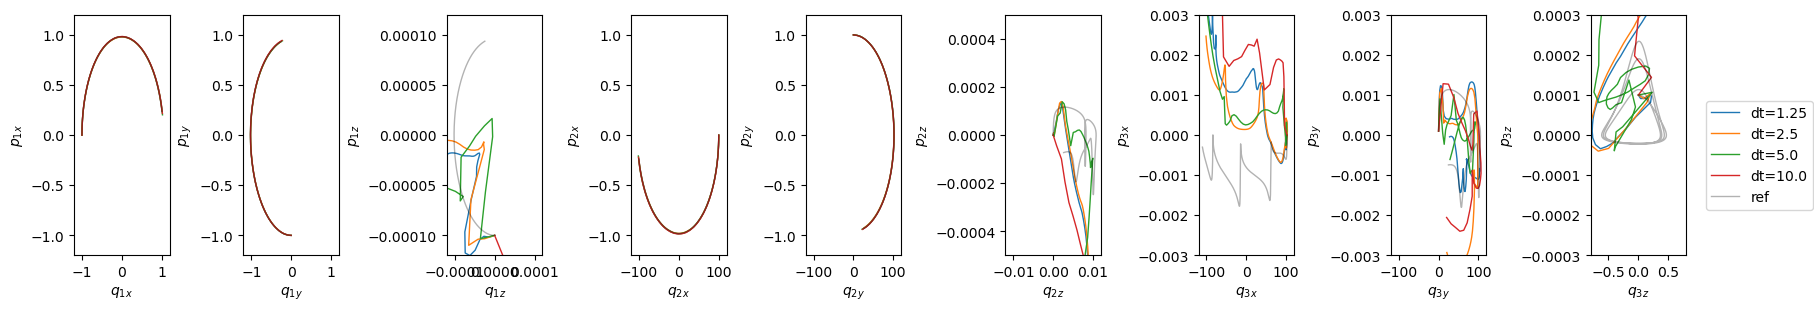

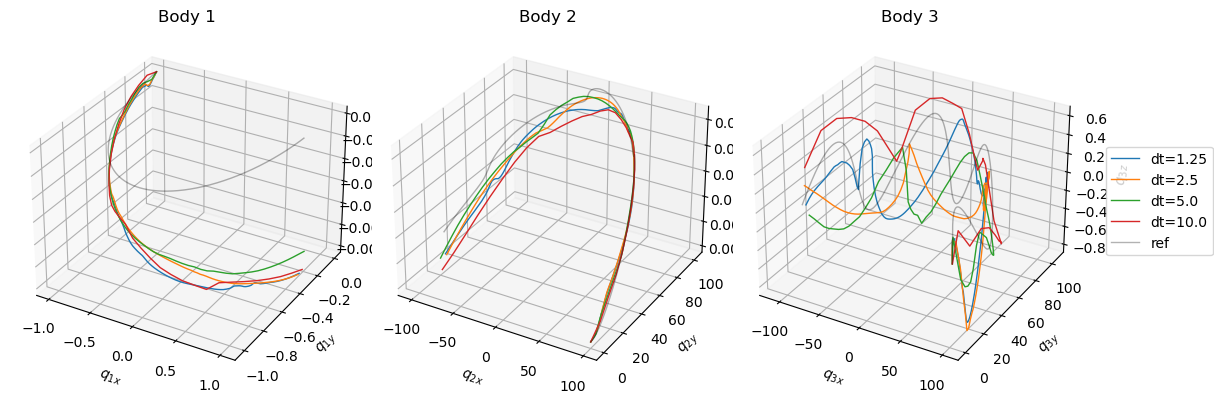

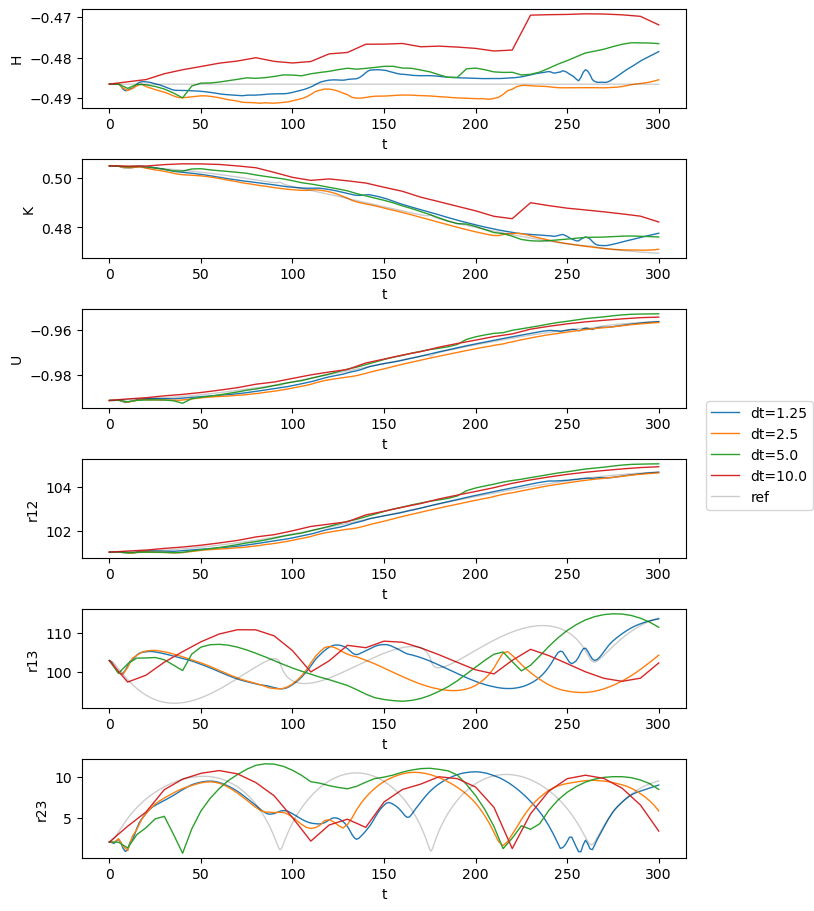

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 300.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(241, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 300.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(241, 18)))
After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 300.0], dt=2.5, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.0

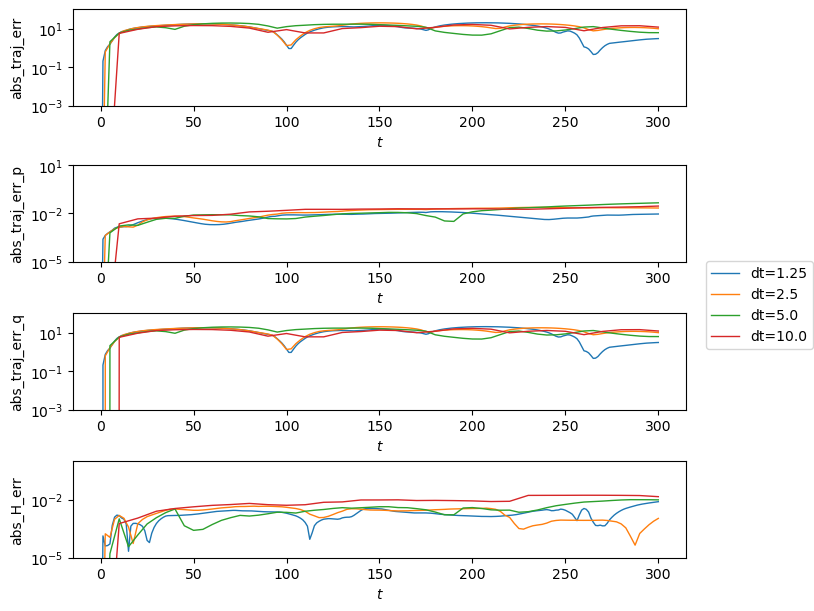

Model: IdEnf: Data uniform(-10,10) version4, traj_idx = 1
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3/predictions/4000x1.25/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3/predictions/2000x2.5/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3/predictions/1000x5.0/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3/predictions/500x10.0/


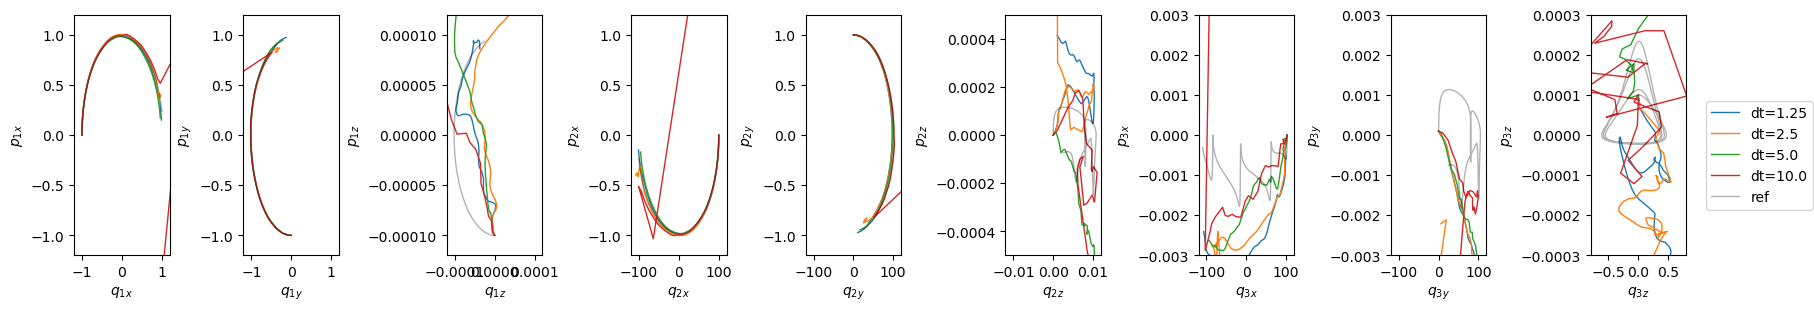

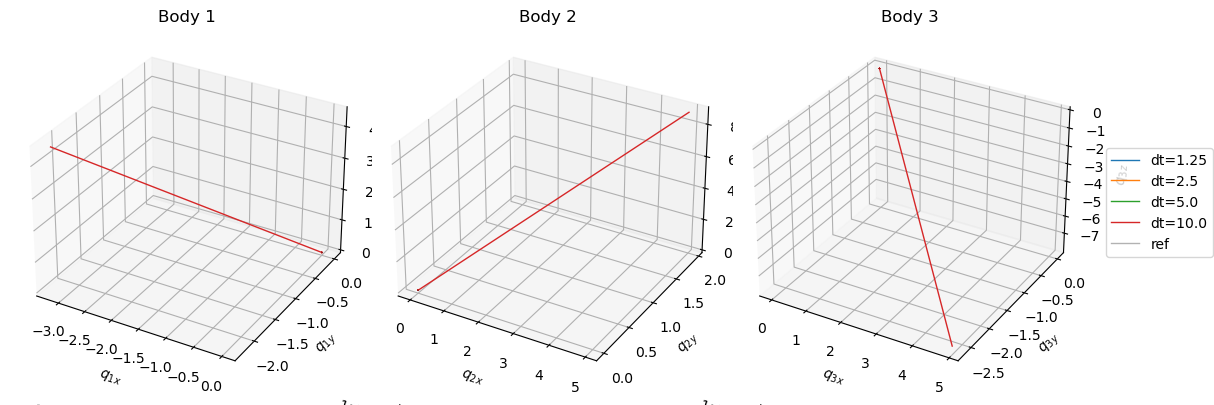

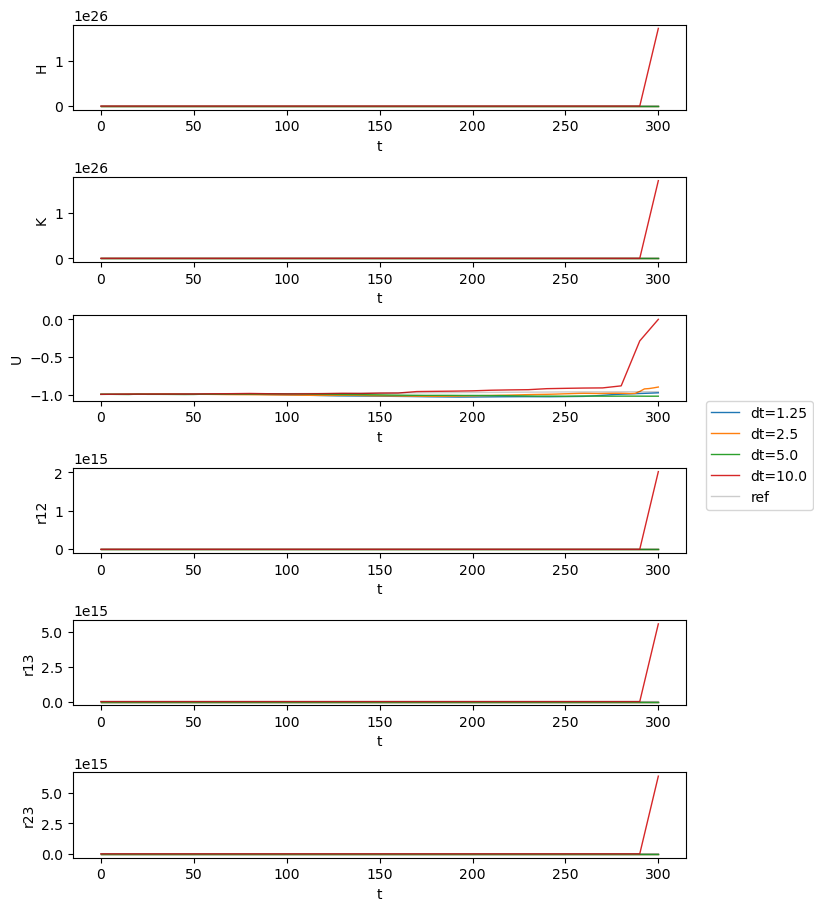

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 300.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(241, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 300.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(241, 18)))
After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 300.0], dt=2.5, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.0

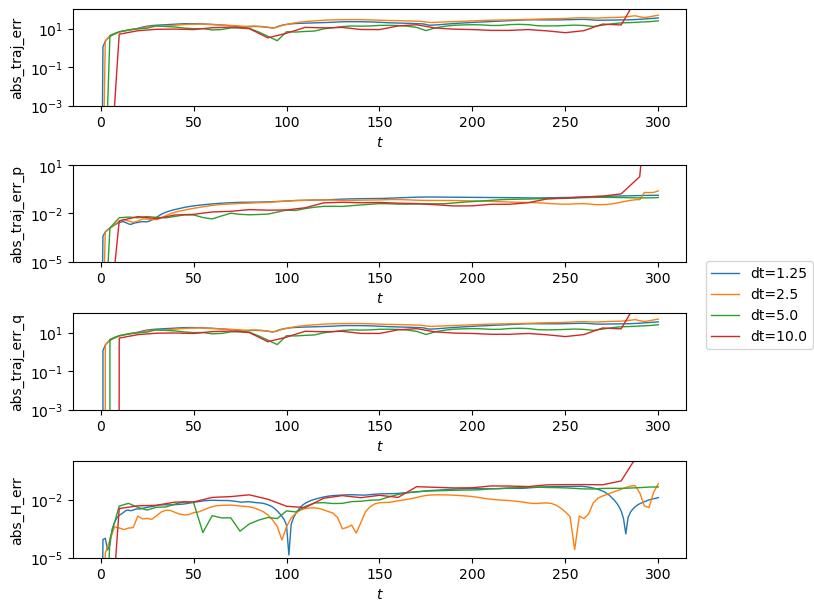

In [26]:
dt_list = [1.25, 2.5, 5.0, 10.0]

threebody = ThreeBody(m1=100., m2=1., m3=0.001)
funcs = {
    "H": threebody.compute_hamiltonian,
    "K": threebody.compute_kinetic_energy,
    "U": threebody.compute_potential_energy,
    "r12": threebody.compute_r12,
    "r13": threebody.compute_r13,
    "r23": threebody.compute_r23,
}

for label, model_dir in model_dirs.items():
    for traj_idx in [1,]:
        print(f"Model: {label}, traj_idx = {traj_idx}")
        compare_dt(dt_list, traj_idx, model_dir, funcs, t_range=(0, 300), show_errors=True, 
                   phase_space_axis_lims=[
                        [(-1.2, 1.2), (-1.2, 1.2)], [(-1.2, 1.2), (-1.2, 1.2)], [(-1.2e-4, 1.2e-4), (-1.2e-4, 1.2e-4)],
                        [(-120, 120), (-1.2, 1.2)], [(-120, 120), (-1.2, 1.2)], [(-0.012, 0.012), (-5e-4, 5e-4)],
                        [(-120, 120), (-3.0e-3, 3.0e-3)], [(-120, 120), (-3.0e-3, 3.0e-3)], [(-0.8, 0.8), (-3e-4, 3e-4)]
                   ],
                   error_names=["abs_traj_err", "abs_traj_err_p", "abs_traj_err_q", "abs_H_err"],
                   error_ylims=[(1e-3, 1e2), (1e-5, 1e1), (1e-3, 1e2), (1e-5, 1e0)],
                )

#### Vary model

dt = 1.25, traj_idx = 1
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241106-003511_hfz5i3/predictions/4000x1.25/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241107-155033_watfae/predictions/4000x1.25/
Using predictions in /workspace/projects_rui/learnsolnmap/deep_learning/logs/eval/runs/20241107-154952_5tlzlz/predictions/4000x1.25/


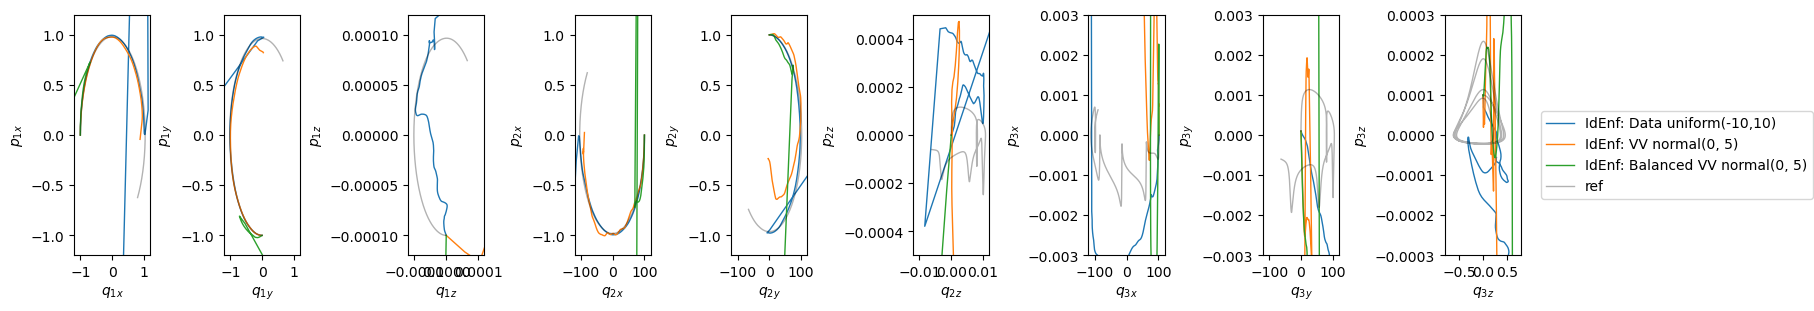

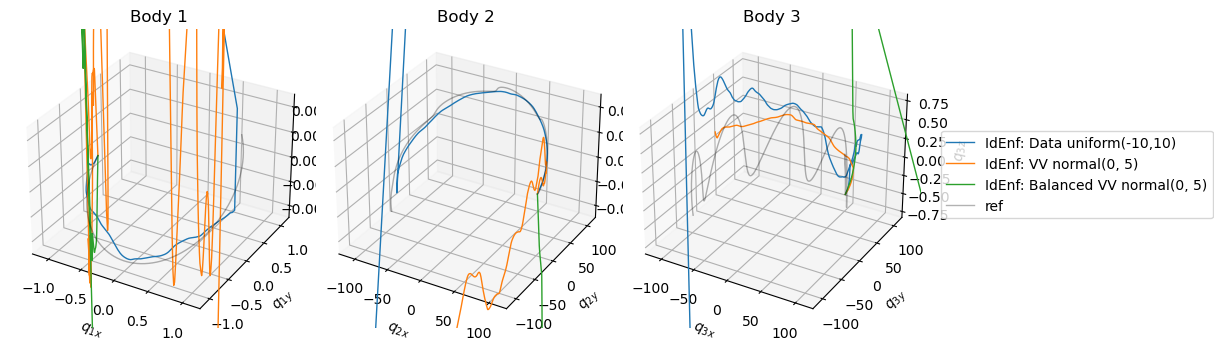

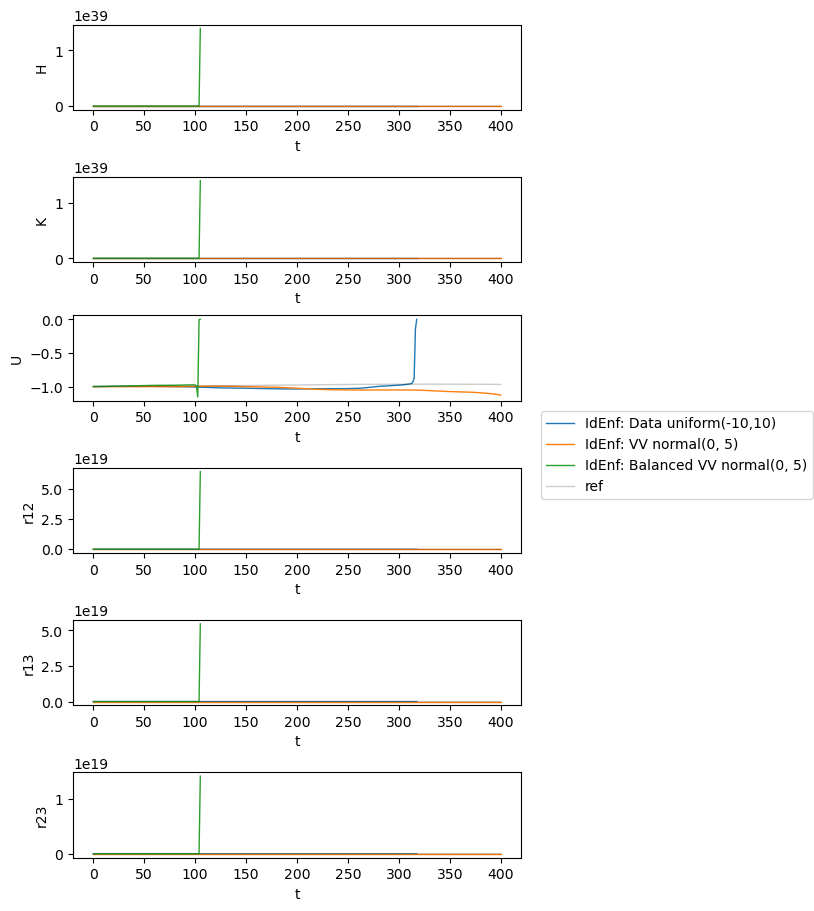

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 400.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(321, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 400.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(321, 18)))
After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 400.0], dt=1.25, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.

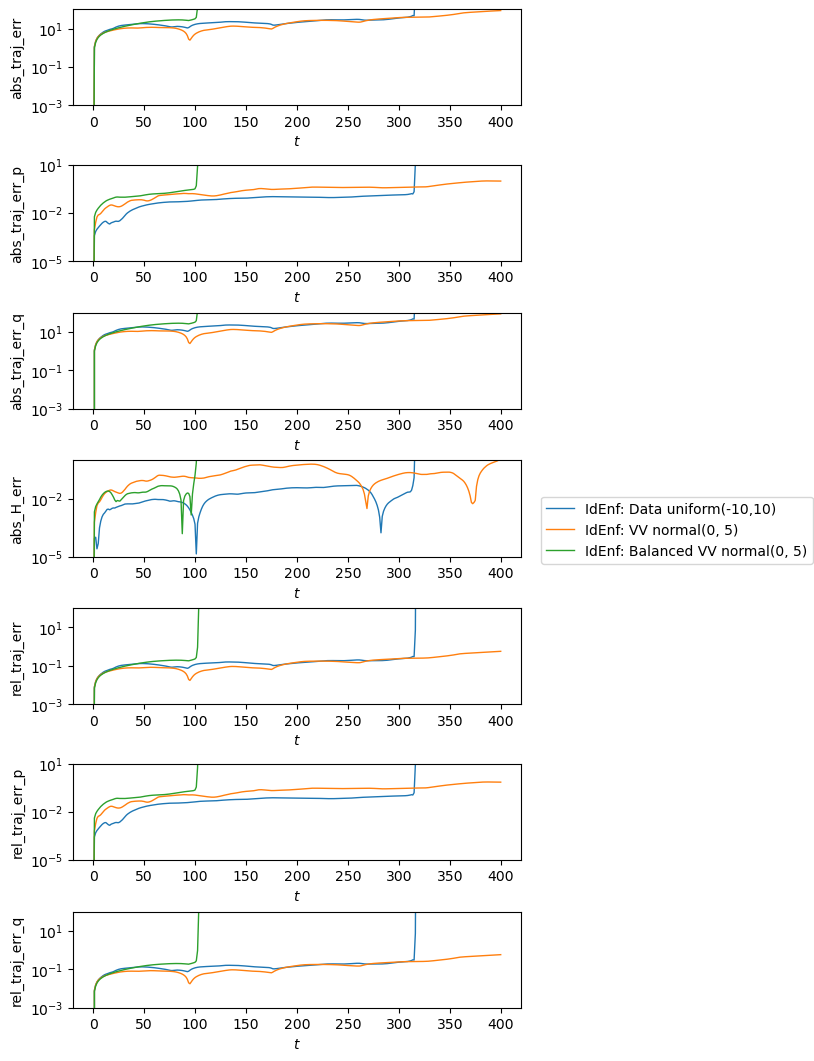

In [20]:
threebody = ThreeBody(m1=100., m2=1., m3=0.001)
funcs = {
    "H": threebody.compute_hamiltonian,
    "K": threebody.compute_kinetic_energy,
    "U": threebody.compute_potential_energy,
    "r12": threebody.compute_r12,
    "r13": threebody.compute_r13,
    "r23": threebody.compute_r23,
}

for dt in [1.25]:
    for traj_idx in [1,]:
        print(f"dt = {dt}, traj_idx = {traj_idx}")
        compare_models(model_dirs, dt, traj_idx, funcs, t_range=(0, 400), show_errors=True,
                       phase_space_axis_lims=[
                        [(-1.2, 1.2), (-1.2, 1.2)], [(-1.2, 1.2), (-1.2, 1.2)], [(-1.2e-4, 1.2e-4), (-1.2e-4, 1.2e-4)],
                        [(-120, 120), (-1.2, 1.2)], [(-120, 120), (-1.2, 1.2)], [(-0.012, 0.012), (-5e-4, 5e-4)],
                        [(-120, 120), (-3.0e-3, 3.0e-3)], [(-120, 120), (-3.0e-3, 3.0e-3)], [(-0.8, 0.8), (-3e-4, 3e-4)]
                   ],
                   error_names=["abs_traj_err", "abs_traj_err_p", "abs_traj_err_q", "abs_H_err",
                                "rel_traj_err", "rel_traj_err_p", "rel_traj_err_q"],
                   error_ylims=[(1e-3, 1e2), (1e-5, 1e1), (1e-3, 1e2), (1e-5, 1e0), 
                                (1e-3, 1e2), (1e-5, 1e1), (1e-3, 1e2)],
                )

#### Valid prediction time 

In [ ]:
def compare_T_valid_vs_t_for_models(dt_list, traj_idx, model_dirs, error_name, error_threshold=1e-2, 
                                    figsize=(6, 3), legend_labels=None, title=None, log_xscale=False, log_yscale=False):
    
    if legend_labels is None:
        legend_labels = list(model_dirs.keys())

    if title is None:
        title = f"Valid prediction criteria: {error_name} < {error_threshold}"

    fig, axes = plt.subplots(2, 1, figsize=figsize, layout='constrained')

    lines = []
    for model_dir, label in zip(model_dirs.values(), legend_labels):
        trajs = []
        dt_list_existed = []
        for dt in dt_list:
            subdir = glob.glob(f"{model_dir}/predictions/*x{dt}/")
            if not subdir:
                print(f"No predictions found with dt={dt}")
                continue
            elif len(subdir) > 1:
                print(f"Multiple directories found with dt={dt}. Using the first one.")
                subdir = subdir[0]
            else:
                subdir = subdir[0]
            print(f"Using predictions in {subdir}")
            traj = Trajectory.load_from_file(f"{subdir}/traj{traj_idx}.csv", dt)
            trajs.append(traj)
            dt_list_existed.append(dt)
        
        ref_traj = Trajectory.load_from_file(OMEGA_50_REF_TRAJ_FILEPATHS[traj_idx], OMEGA_50_REF_TRAJ_DT)
        T_valids = [traj.valid_prediction_time(ref_traj, error_name, error_threshold) for traj in trajs]
        nsteps_valids = [int(T / dt) for dt, T in zip(dt_list_existed, T_valids)]
        
        line1, = axes[0].plot(dt_list_existed, T_valids, ".-", label=label)
        axes[1].plot(dt_list_existed, nsteps_valids, ".-", label=label)
        lines.append(line1)
    
    # axes[1].set_ylim(0, 300)
    
    fig.suptitle(title)
    axes[0].set_xlabel("$t$")
    axes[1].set_xlabel("$t$")
    axes[0].set_ylabel("$T_{valid}$")
    axes[1].set_ylabel("$nsteps_{valid}$")
    
    for ax in axes:
        if log_xscale:
            ax.set_xscale('log')
        if log_yscale:
            ax.set_yscale('log')

    # Place a single legend outside the right of the subplots
    fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
    # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    plt.show()

    return

def compare_T_valid_vs_t_for_initial_states(dt_list, traj_indices, model_dir, error_name, error_threshold=1e-2, 
                                    figsize=(6, 3), legend_labels=None, title=None):
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(idx) for idx in traj_indices]  # Default labels for legends
    
    if title is None:
        title = f"Valid prediction criteria: {error_name} < {error_threshold}"

    fig, axes = plt.subplots(2, 1, figsize=figsize, layout='constrained')

    lines = []
    for traj_idx, label in zip(traj_indices, legend_labels):
        trajs = []
        for dt in dt_list:
            subdir = glob.glob(f"{model_dir}/predictions/*x{dt}/")
            if not subdir:
                print(f"No predictions found with dt={dt}")
                return
            elif len(subdir) > 1:
                print(f"Multiple directories found with dt={dt}. Using the first one.")
                subdir = subdir[0]
            else:
                subdir = subdir[0]
            print(f"Using predictions in {subdir}")
            traj = Trajectory.load_from_file(f"{subdir}/traj{traj_idx}.csv", dt)
            trajs.append(traj)

        ref_traj = Trajectory.load_from_file(OMEGA_50_REF_TRAJ_FILEPATHS[traj_idx], OMEGA_50_REF_TRAJ_DT)
        T_valids = [traj.valid_prediction_time(ref_traj, error_name, error_threshold) for traj in trajs]
        nsteps_valids = [int(T / dt) for dt, T in zip(dt_list, T_valids)]
        
        line1, = axes[0].plot(dt_list, T_valids, ".-", label=label)
        axes[1].plot(dt_list, nsteps_valids, ".-", label=label)
        lines.append(line1)
    
    fig.suptitle(title)
    axes[0].set_xlabel("$t$")
    axes[1].set_xlabel("$t$")
    axes[0].set_ylabel("$T_{valid}$")
    axes[1].set_ylabel("$nsteps_{valid}$")
        
    # Place a single legend outside the right of the subplots
    fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
    # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    plt.show()

    return

In [ ]:
dt_list = [0.015625, 0.03125, 0.0625, 0.125, 0.15625, 0.25, 0.3125, 0.5]

for traj_idx in [1,]:
    print(f"traj_idx = {traj_idx}")
    compare_T_valid_vs_t_for_models(
        dt_list=dt_list,
        traj_idx=traj_idx,
        model_dirs=model_dirs,
        error_name="rel_traj_err",
        error_threshold=0.1,
        figsize=(8, 5),
        log_xscale=False,
        log_yscale=False,
    )